# CCF — RDD Implementation

**Connected Component Finder** using the PySpark **RDD API**.

> Kardes et al., *CCF: Fast and Scalable Connected Component Computation in MapReduce*

### Algorithm
Iterate two MapReduce jobs until convergence:
1. **CCF-Iterate** — for each node, find the minimum neighbour ID and propagate it
2. **CCF-Dedup** — remove duplicate pairs with `distinct()`

Stop when no new pairs are emitted (accumulator == 0).

> **Before running:** make sure the data files exist by running `python/generate_graphs.py` first.

## 1. Configuration

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, sys, subprocess

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'pyspark', 'matplotlib', '-q'], check=True)

# local[*] -> embedded; spark://spark-master:7077 -> Docker cluster
SPARK_MASTER = 'local[*]'
DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/M2_Projects/Big Data/data' if IN_COLAB else os.path.join(os.path.dirname(os.getcwd()), 'data')

# Verify that graphs have been generated
REQUIRED = ['graph_small.txt', 'graph_medium.txt', 'graph_large.txt']
missing = [f for f in REQUIRED if not os.path.exists(os.path.join(DATA_DIR, f))]
if missing:
    raise FileNotFoundError(
        f"Missing graph files: {missing}\n"
        f"Run python/generate_graphs.py first (generates files in {DATA_DIR})"
    )

print(f'Spark master : {SPARK_MASTER}')
print(f'Data dir     : {DATA_DIR}')
print(f'Graphs found : {REQUIRED}')

Spark master : local[*]
Data dir     : /content/drive/MyDrive/Colab Notebooks/M2_Projects/Big Data/data
Graphs found : ['graph_small.txt', 'graph_medium.txt', 'graph_large.txt']


## 2. Start SparkContext

In [4]:
import time
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pyspark import SparkContext, SparkConf

conf = (
    SparkConf()
    .setAppName('CCF-RDD-Notebook')
    .setMaster(SPARK_MASTER)
    .set('spark.ui.showConsoleProgress', 'false')
)
sc = SparkContext(conf=conf)
sc.setLogLevel('WARN')
print(f'Spark version : {sc.version}')
print(f'Master        : {sc.master}')

Spark version : 4.0.2
Master        : local[*]


## 3. Load edges

In [5]:
def load_edges(sc, path):
    return (
        sc.textFile(path)
        .filter(lambda line: line.strip() and not line.startswith('#'))
        .map(lambda line: tuple(map(int, line.strip().split())))
    )

small_path = os.path.join(DATA_DIR, 'graph_small.txt')
edge_rdd = load_edges(sc, small_path)
edge_rdd.cache()
print(f'Edges loaded: {edge_rdd.count()}')
print('First 5:', edge_rdd.take(5))

Edges loaded: 1000
First 5: [(1, 156), (1, 267), (1, 272), (1, 307), (1, 337)]


## 4. CCF-Iterate

**Map:** for each edge `(a, b)` emit both `(a, b)` and `(b, a)`  
**Reduce:** group neighbours per node, find minimum, propagate

In [6]:
def ccf_iterate(rdd, new_pair_acc):
    """One CCF-Iterate step: bidirectionalise, group, find min, propagate."""
    def reduce_fn(kv):
        key, values = kv
        val_list = list(values)
        min_val = min(val_list + [key])   # smallest neighbour (or self)
        out = []
        if min_val < key:
            # Assign this node to the min component
            out.append((key, min_val))
            # Forward the min label to all other neighbours — these are "new pairs"
            for v in val_list:
                if v != min_val:
                    out.append((v, min_val))
                    new_pair_acc.add(1)
        return out

    return (
        rdd.flatMap(lambda p: [(p[0], p[1]), (p[1], p[0])])  # bidirectional
           .groupByKey()
           .flatMap(reduce_fn)
    )

## 5. CCF-Dedup + main loop

In [7]:
def run_ccf(sc, edge_rdd):
    """Full CCF loop. Returns (result_rdd, iterations, per_iter_stats)."""
    current = edge_rdd
    iteration = 0
    per_iter = []   # list of (iteration, pair_count, new_pairs, elapsed_s)
    while True:
        iteration += 1
        t_iter = time.time()
        acc = sc.accumulator(0)
        iterated = ccf_iterate(current, acc)
        deduped = iterated.distinct().cache()
        count = deduped.count()          # triggers computation
        dt = time.time() - t_iter
        per_iter.append((iteration, count, acc.value, round(dt, 3)))
        print(f'  Iteration {iteration}: {count} pairs, newPairs={acc.value}  ({dt:.2f}s)')
        current.unpersist()
        current = deduped
        if acc.value == 0:
            break
    return current, iteration, per_iter

## 6. Correctness test (paper Figure 5)

Edges: (0,1),(1,2),(1,3),(3,4),(5,6),(6,7)  
Expected: **2 components** — {0,1,2,3,4} and {5,6,7}

In [8]:
paper_edges = sc.parallelize([(0,1),(1,2),(1,3),(3,4),(5,6),(6,7)])
res_paper, iters_paper, _ = run_ccf(sc, paper_edges)
comps = res_paper.map(lambda kv: kv[1]).distinct().count()
print(f'\nResult: {comps} components in {iters_paper} iterations  '
      f"{('PASS' if comps == 2 else 'FAIL')} (expected 2)")

  Iteration 1: 10 pairs, newPairs=4  (2.52s)
  Iteration 2: 8 pairs, newPairs=9  (1.81s)
  Iteration 3: 6 pairs, newPairs=4  (1.48s)
  Iteration 4: 6 pairs, newPairs=0  (1.49s)

Result: 2 components in 4 iterations  PASS (expected 2)


## 7. Run on graph_small — detailed iteration trace

In [9]:
t0 = time.time()
result_rdd, n_iters, per_iter = run_ccf(sc, edge_rdd)
elapsed = time.time() - t0

num_components = result_rdd.map(lambda kv: kv[1]).distinct().count()

print(f"\n{'='*45}")
print(f'Graph        : graph_small.txt')
print(f'Iterations   : {n_iters}')
print(f'Components   : {num_components}')
print(f'Elapsed time : {elapsed:.3f}s')
print(f"{'='*45}")

print(f"\n{'Iter':>5} {'Pairs':>8} {'NewPairs':>10} {'Time (s)':>10}")
print('-' * 37)
for it, cnt, np_, dt in per_iter:
    print(f'{it:>5} {cnt:>8,} {np_:>10,} {dt:>10.3f}')

  Iteration 1: 1582 pairs, newPairs=1209  (1.48s)
  Iteration 2: 2357 pairs, newPairs=2260  (1.66s)
  Iteration 3: 2086 pairs, newPairs=3839  (2.61s)
  Iteration 4: 641 pairs, newPairs=3269  (2.72s)
  Iteration 5: 499 pairs, newPairs=284  (1.95s)
  Iteration 6: 499 pairs, newPairs=0  (1.35s)

Graph        : graph_small.txt
Iterations   : 6
Components   : 1
Elapsed time : 11.783s

 Iter    Pairs   NewPairs   Time (s)
-------------------------------------
    1    1,582      1,209      1.481
    2    2,357      2,260      1.657
    3    2,086      3,839      2.606
    4      641      3,269      2.718
    5      499        284      1.946
    6      499          0      1.351


## 8. Run on all graph sizes

In [10]:
results = []
all_per_iter = {}

for name in ['graph_small.txt', 'graph_medium.txt', 'graph_large.txt']:
    path = os.path.join(DATA_DIR, name)
    print(f'\n── {name} ──')
    rdd = load_edges(sc, path)
    rdd.cache()
    n_edges = rdd.count()
    t0 = time.time()
    res, iters, pit = run_ccf(sc, rdd)
    elapsed = time.time() - t0
    n_comp = res.map(lambda kv: kv[1]).distinct().count()
    results.append({'graph': name, 'edges': n_edges, 'iterations': iters,
                    'components': n_comp, 'time_s': round(elapsed, 3)})
    all_per_iter[name] = pit

hdr = f"{'Graph':<25} {'Edges':>10} {'Iters':>7} {'Components':>12} {'Time (s)':>10}"
print('\n' + hdr)
print('-' * len(hdr))
for r in results:
    print(f"{r['graph']:<25} {r['edges']:>10,} {r['iterations']:>7} {r['components']:>12} {r['time_s']:>10}")


── graph_small.txt ──
  Iteration 1: 1582 pairs, newPairs=1209  (1.23s)
  Iteration 2: 2357 pairs, newPairs=2260  (1.37s)
  Iteration 3: 2086 pairs, newPairs=3839  (1.23s)
  Iteration 4: 641 pairs, newPairs=3269  (1.22s)
  Iteration 5: 499 pairs, newPairs=284  (1.15s)
  Iteration 6: 499 pairs, newPairs=0  (1.87s)

── graph_medium.txt ──
  Iteration 1: 90566 pairs, newPairs=81806  (2.34s)
  Iteration 2: 151612 pairs, newPairs=161514  (2.51s)
  Iteration 3: 42651 pairs, newPairs=287827  (2.05s)
  Iteration 4: 10009 pairs, newPairs=65309  (1.44s)
  Iteration 5: 9999 pairs, newPairs=20  (1.25s)
  Iteration 6: 9999 pairs, newPairs=0  (1.16s)

── graph_large.txt ──
  Iteration 1: 909097 pairs, newPairs=819132  (9.15s)
  Iteration 2: 1656237 pairs, newPairs=1624515  (16.90s)
  Iteration 3: 1408637 pairs, newPairs=3190108  (22.80s)
  Iteration 4: 126640 pairs, newPairs=2641761  (8.79s)
  Iteration 5: 99999 pairs, newPairs=53282  (2.80s)
  Iteration 6: 99999 pairs, newPairs=0  (3.85s)

Graph  

## 9. Visualisation

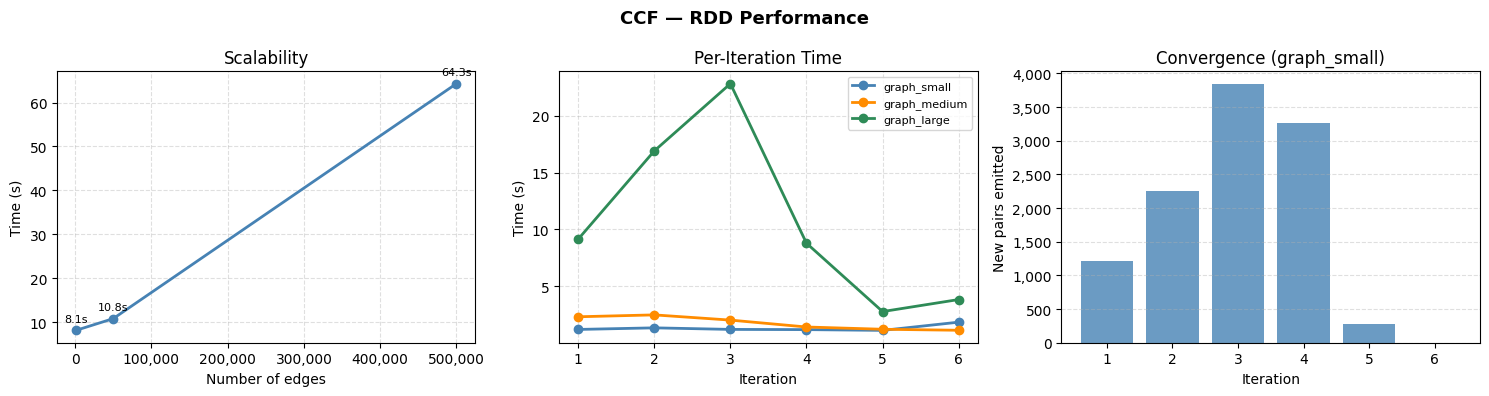

Saved to /content/drive/MyDrive/Colab Notebooks/M2_Projects/Big Data/data/rdd_results.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('CCF — RDD Performance', fontsize=13, fontweight='bold')

# ── 1. Scalability: time vs edges ─────────────────────────────────────────────
ax1 = axes[0]
edges_v = [r['edges'] for r in results]
times_v = [r['time_s'] for r in results]
ax1.plot(edges_v, times_v, marker='o', color='steelblue', lw=2)
for e, t in zip(edges_v, times_v):
    ax1.annotate(f'{t:.1f}s', xy=(e, t), xytext=(0, 6), textcoords='offset points',
                 ha='center', fontsize=8)
ax1.set_xlabel('Number of edges'); ax1.set_ylabel('Time (s)')
ax1.set_title('Scalability')
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax1.grid(linestyle='--', alpha=0.4)

# ── 2. Per-iteration time for each graph ──────────────────────────────────────
ax2 = axes[1]
colors = ['steelblue', 'darkorange', 'seagreen']
for idx, (name, pit) in enumerate(all_per_iter.items()):
    iters = [p[0] for p in pit]
    times = [p[3] for p in pit]
    ax2.plot(iters, times, marker='o', color=colors[idx % len(colors)],
             label=name.replace('.txt', ''), lw=2)
ax2.set_xlabel('Iteration'); ax2.set_ylabel('Time (s)')
ax2.set_title('Per-Iteration Time')
ax2.legend(fontsize=8); ax2.grid(linestyle='--', alpha=0.4)

# ── 3. New pairs per iteration — convergence signal (graph_small) ─────────────
ax3 = axes[2]
key_small = 'graph_small.txt'
if key_small in all_per_iter:
    pit_s   = all_per_iter[key_small]
    iters_s = [p[0] for p in pit_s]
    new_p   = [p[2] for p in pit_s]
    ax3.bar(iters_s, new_p, color='steelblue', alpha=0.8)
    ax3.set_xlabel('Iteration'); ax3.set_ylabel('New pairs emitted')
    ax3.set_title('Convergence (graph_small)')
    ax3.set_xticks(iters_s)
    ax3.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
    ax3.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
out_path = os.path.join(DATA_DIR, 'rdd_results.png')
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved to {out_path}')

In [12]:
sc.stop()